<a href="https://colab.research.google.com/github/stephleao/wmc-desafio-streaming-churn/blob/steph%2Ffeature%2Frefactor/analise_probabilidade_amostragem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Configurações Iniciais**

In [157]:
# ==============================
# IMPORTAÇÕES
# ==============================

import math  # Para funcoes matematicas, como calculo de tamanho de amostra
import numpy as np  # Para operacoes numericas e arrays
import pandas as pd  # Para manipulaco e analise de data frames
from IPython.display import display, Markdown  # Para exibir outputs formatados

# Bibliotecas para criacao de graficos
import seaborn as sns
import matplotlib.pyplot as plt

# Bibliotecas para testes estatisticos e de hipoteses
from scipy.stats import ttest_ind, chi2_contingency, f_oneway, kruskal


# 1. CARREGAMENTO DA BASE CORRIGIDO (Adicionado o sep=';')
url = 'https://raw.githubusercontent.com/stephleao/wmc-desafio-streaming-churn/refs/heads/main/clientes.csv'
df = pd.read_csv(url, sep=';')

# Armazena a paleta do Seaborn que sera usada em todo o trabalho
paleta = 'flare'
cores = sns.color_palette(paleta, n_colors=2)  # Cores fixas para os 2 status (Churn / Nao Churn)


In [158]:
print("=== 1. DIAGNÓSTICO INICIAL DOS DADOS ===")
print(f"Total de registros originais: {df.shape[0]} linhas e {df.shape[1]} colunas\n")

# 2. VERIFICAÇÃO DE SAÚDE DOS DADOS
print("--- Tipos de Dados ---")
print(df.dtypes)

print("\n--- Valores Ausentes (Nulos) por Coluna ---")
print(df.isna().sum())

print(f"\nLinhas duplicadas identificadas: {df.duplicated().sum()}")

# 3. LIMPEZA (Removendo duplicados, se existirem)
df = df.drop_duplicates()

# 4. CRIAÇÃO DOS GRUPOS COM BASE NO TEMPO DE ASSINATURA DOS CANCELADOS
# Consideramos quem cancelou (cancelou == 1 ou 'Sim') e mapeamos o tempo
# Adaptando a regra do negócio para as colunas reais da sua base:
condicoes = [
    (df['cancelou'].isin([1, 'Sim', 'sim', 'S']) & (df['tempo_assinatura_meses'] <= 6)),
    (df['cancelou'].isin([1, 'Sim', 'sim', 'S']) & (df['tempo_assinatura_meses'] > 24))
]
nomes_grupos = ['Ultimos 6 meses', 'Mais de 24 meses']

# Criando a nova coluna de segmentação
df['grupo_cancelamento'] = np.select(condicoes, nomes_grupos, default='Outros Periodos / Ativos')

print("\n=== 2. QUANTIDADE DE CLIENTES POR GRUPO ===")
print(df['grupo_cancelamento'].value_counts())

=== 1. DIAGNÓSTICO INICIAL DOS DADOS ===
Total de registros originais: 200 linhas e 7 colunas

--- Tipos de Dados ---
cliente_id                  int64
idade                       int64
tempo_assinatura_meses      int64
frequencia_uso_mensal       int64
regiao                     object
mensalidade               float64
cancelou                    int64
dtype: object

--- Valores Ausentes (Nulos) por Coluna ---
cliente_id                0
idade                     0
tempo_assinatura_meses    0
frequencia_uso_mensal     0
regiao                    0
mensalidade               0
cancelou                  0
dtype: int64

Linhas duplicadas identificadas: 0

=== 2. QUANTIDADE DE CLIENTES POR GRUPO ===
grupo_cancelamento
Outros Periodos / Ativos    159
Mais de 24 meses             32
Ultimos 6 meses               9
Name: count, dtype: int64


In [159]:
# Ver os nomes reais de todas as colunas da base
print(df.columns.tolist())

['cliente_id', 'idade', 'tempo_assinatura_meses', 'frequencia_uso_mensal', 'regiao', 'mensalidade', 'cancelou', 'grupo_cancelamento']


In [160]:
# ==============================
# FUNCOES AUXILIARES DE GRAFICO
# ==============================
# Centralizam padroes que se repetiam em varios graficos

def iniciar_grafico(titulo, xlabel, ylabel, figsize=(8, 5)):
  """Cria a figura e ja aplica o padrao visual usado nos graficos: grid, titulo e rotulos dos eixos."""
  plt.figure(figsize=figsize)
  plt.grid(axis='y', linestyle='--', alpha=0.5)
  plt.title(titulo, fontweight='bold')
  plt.xlabel(xlabel)
  plt.ylabel(ylabel)


def rotulo_acima_da_barra(ax, formato='{:.2f}%'):
  """Escreve o valor de cada barra logo acima dela (bom para barras simples/agrupadas)."""
  for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
      ax.annotate(
        formato.format(altura),
        (p.get_x() + p.get_width() / 2, altura),
        ha='center', va='center',
        xytext=(0, 7), textcoords='offset points',
        fontweight='bold'
      )


def rotulo_dentro_da_barra(patches, formato='{:.2f}%', cor='black'):
  """Escreve o valor centralizado dentro do segmento da barra (bom para barras empilhadas)."""
  for p in patches:
    largura, altura = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if altura > 0:
      plt.text(
        x + largura / 2, y + altura / 2,
        formato.format(altura),
        ha='center', va='center', fontweight='bold', color=cor
      )

In [161]:
# ==========================================
# SEGMENTAÇÃO DA BASE POR STATUS DE CHURN
# ==========================================

# Objetivo:
# Filtra clientes que cancelaram o serviço (churn) e não churn
# Condição: cancelou == 1
# Condição: cancelou == 0

cancelaram = df[df['cancelou'] == 1]
ativos = df[df['cancelou'] == 0]

In [162]:
# ==========================================
# DISTRIBUIÇÃO DA VARIÁVEL ALVO (CHURN)
# ==========================================

# Objetivo:
# - entender o balanceamento da variável alvo (churn vs não churn)

display(Markdown("## Taxa de clientes por status de Churn"))
display(Markdown("---"))

percentual = (
    df['cancelou']
    .value_counts(normalize=True)
    .mul(100)
    .rename(index={0: 'Não Churn', 1: 'Churn'})
    .round(2)
    .reset_index()
)

# Ajuste de nomes das colunas para leitura mais clara
percentual.columns = ['Status', 'Percentual (%)']

# Exibição final da tabela formatada
display(percentual)

# Percentual de churn (linha onde Status == 'Churn')
churn_rate = percentual.loc[percentual['Status'] == 'Churn', 'Percentual (%)'].values[0]

display(Markdown("---"))
print(f'Percentual de Churn é de: {churn_rate:.2f}%')

## Taxa de clientes por status de Churn

---

,Status,Percentual (%)
0,Não Churn,72.0
1,Churn,28.0


---

Percentual de Churn é de: 28.00%


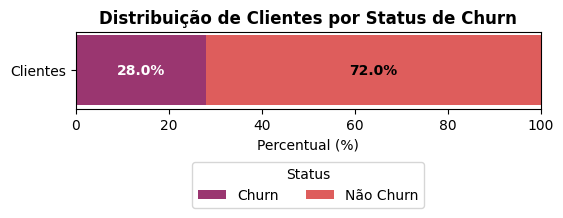

In [163]:
# Armazena as porcentagens dos status de churn
perc_nao_churn = percentual.loc[percentual['Status'] == 'Não Churn', 'Percentual (%)'].item()
perc_churn = percentual.loc[percentual['Status'] == 'Churn', 'Percentual (%)'].item()

fig, ax = plt.subplots(figsize=(6, 1)) # Ajusta o tamanho da figura para melhor visualizacao horizontal

# Plota os segmentos das porcentagens com a menor primeiro
ax.barh(y='Clientes', width=perc_churn, label='Churn', color=cores[1])
ax.barh(y='Clientes', width=perc_nao_churn, left=perc_churn, label='Não Churn', color=cores[0])

# Adiciona titulo e rotulos
ax.set_title('Distribuição de Clientes por Status de Churn', fontweight='bold')
ax.set_xlabel('Percentual (%)')
ax.set_xlim(0, 100)

# Adiciona as porcentagens nas barras para melhor legibilidade
ax.text(perc_churn / 2, 0, f'{perc_churn}%', ha='center', va='center', color='white', fontweight='bold')
ax.text(perc_churn + perc_nao_churn / 2, 0, f'{perc_nao_churn}%', ha='center', va='center', color='black', fontweight='bold')

# Adiciona lengenda dos dados
ax.legend(title='Status', loc='upper center', bbox_to_anchor=(0.5, -0.6), ncol=2)
plt.show()

In [164]:
# ==========================================
# CRIAÇÃO DE VARIÁVEL CATEGÓRICA (GRUPO DE TEMPO)
# ==========================================

# Objetivo:
# - Facilitar análise de churn por estágio do cliente
# - Permitir comparação entre perfis de curto, médio e longo prazo

df['grupo_tempo'] = pd.cut(
    df['tempo_assinatura_meses'],  # variável contínua original
    bins=[0, 6, 24, df['tempo_assinatura_meses'].max()],  # limites das faixas
    labels=['Até 6 meses', '7 a 24 meses', 'Acima de 24 meses']  # categorias finais
)

In [165]:
# ==========================================
# CHURN POR GRUPO DE TEMPO (TABELA DE CONTINGÊNCIA)
# ==========================================

# Objetivo:
# - comparar risco de churn entre diferentes estágios de relacionamento do cliente

# Denominador:
# - total de clientes dentro de cada grupo de tempo

display(Markdown("## Tabela de contingência entre tempo de assinatura e status"))
display(Markdown("---"))

tabela_churn_periodo = (
    pd.crosstab(
        df['grupo_tempo'],
        df['cancelou'],
        normalize='index'
    )
    .mul(100)
    .round(2)
    .rename(columns={
        0: 'Não churn (%)',
        1: 'Churn (%)'
    })
)

display(
    tabela_churn_periodo.style
        .format("{:.2f}%")
        .background_gradient(cmap=sns.color_palette(paleta, as_cmap=True))
)

## Tabela de contingência entre tempo de assinatura e status

---

cancelou,Não churn (%),Churn (%)
grupo_tempo,,
Até 6 meses,62.50%,37.50%
7 a 24 meses,71.15%,28.85%
Acima de 24 meses,74.19%,25.81%


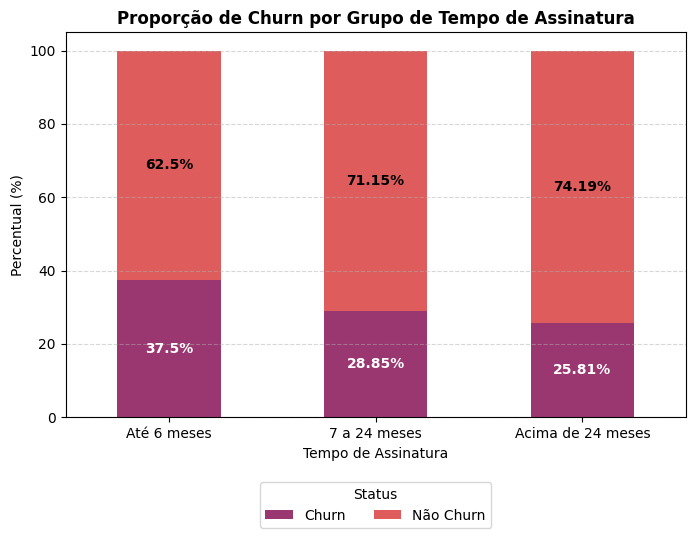

In [166]:
leg_labels_churn = ['Churn', 'Não Churn']

# Plota os segmentos das porcentagens com a menor na base
ax = tabela_churn_periodo[['Churn (%)', 'Não churn (%)']].plot(kind='bar', stacked=True, figsize=(8, 5), color=[cores[1], cores[0]])
plt.xticks(rotation=0) # rotaciona os rotulos dos bins de tempo

# Adiciona grid horizontal para facilitar a leitura
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Adiciona as porcentagens nas barras
# ax.patches seguem a ordem das colunas no plot: primeiro todas de 'Churn (%)',
# depois 'Não churn (%)' - por isso dividimos a lista ao meio para cada cor de texto
metade = len(ax.patches) // 2
rotulo_dentro_da_barra(ax.patches[:metade], formato='{}%', cor='white')
rotulo_dentro_da_barra(ax.patches[metade:], formato='{}%', cor='black')

# Adiciona titulo e rotulos
plt.title('Proporção de Churn por Grupo de Tempo de Assinatura', fontweight='bold')
plt.xlabel('Tempo de Assinatura')
plt.ylabel('Percentual (%)')
plt.legend(title='Status', labels=leg_labels_churn, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.show()

In [167]:
# ==========================================
# ESTATÍSTICAS DESCRITIVAS DA BASE E SEGMENTAÇÃO POR CHURN
# ==========================================

display(Markdown("## Estatísticas descritivas da base"))
display(Markdown("---"))

# ------------------------------------------
# ESTATÍSTICAS GERAIS DA BASE
# ------------------------------------------

# Objetivo:
# - Entender o comportamento geral das variáveis numéricas
# - Identificar possíveis outliers e dispersões relevantes

display(df.describe().T.round(2))
display(Markdown("---"))

# ------------------------------------------
# PERFIL DOS CLIENTES EM CHURN
# ------------------------------------------
# - subconjunto da base onde cancelou == 1

display(Markdown("## Estatísticas descritivas dos clientes com churn"))
display(cancelaram.drop(columns=['cancelou']).describe().T.round(2))
display(Markdown("---"))

# ------------------------------------------
# PERFIL DOS CLIENTES ATIVOS
# ------------------------------------------
# - subconjunto da base onde cancelou == 0

display(Markdown("## Estatísticas descritivas dos clientes sem churn"))
display(ativos.drop(columns=['cancelou']).describe().T.round(2))

## Estatísticas descritivas da base

---

,count,mean,std,min,25%,50%,75%,max
cliente_id,200.0,100.50,57.88,1.00,50.75,100.50,150.25,200.00
idade,200.0,45.26,16.04,18.00,31.75,45.00,59.00,74.00
tempo_assinatura_meses,200.0,30.89,17.68,1.00,16.75,32.00,48.00,59.00
frequencia_uso_mensal,200.0,15.98,8.84,1.00,8.00,17.00,23.00,29.00
mensalidade,200.0,59.13,23.32,21.16,38.81,57.71,79.68,99.98
cancelou,200.0,0.28,0.45,0.00,0.00,0.00,1.00,1.00


---

## Estatísticas descritivas dos clientes com churn

,count,mean,std,min,25%,50%,75%,max
cliente_id,56.0,93.14,51.12,1.00,49.50,88.50,126.25,197.00
idade,56.0,43.29,16.21,18.00,28.75,42.50,56.00,74.00
tempo_assinatura_meses,56.0,29.66,18.79,1.00,14.25,29.50,49.00,59.00
frequencia_uso_mensal,56.0,15.71,9.08,1.00,6.75,15.00,25.00,29.00
mensalidade,56.0,57.33,23.41,21.16,37.84,53.64,79.83,99.98


---

## Estatísticas descritivas dos clientes sem churn

,count,mean,std,min,25%,50%,75%,max
cliente_id,144.0,103.36,60.23,2.00,51.75,104.50,155.50,200.00
idade,144.0,46.03,15.96,18.00,32.00,45.50,59.25,74.00
tempo_assinatura_meses,144.0,31.37,17.27,1.00,18.00,33.00,48.00,59.00
frequencia_uso_mensal,144.0,16.08,8.78,1.00,8.75,17.00,23.00,29.00
mensalidade,144.0,59.83,23.33,21.61,39.30,60.08,78.50,99.73


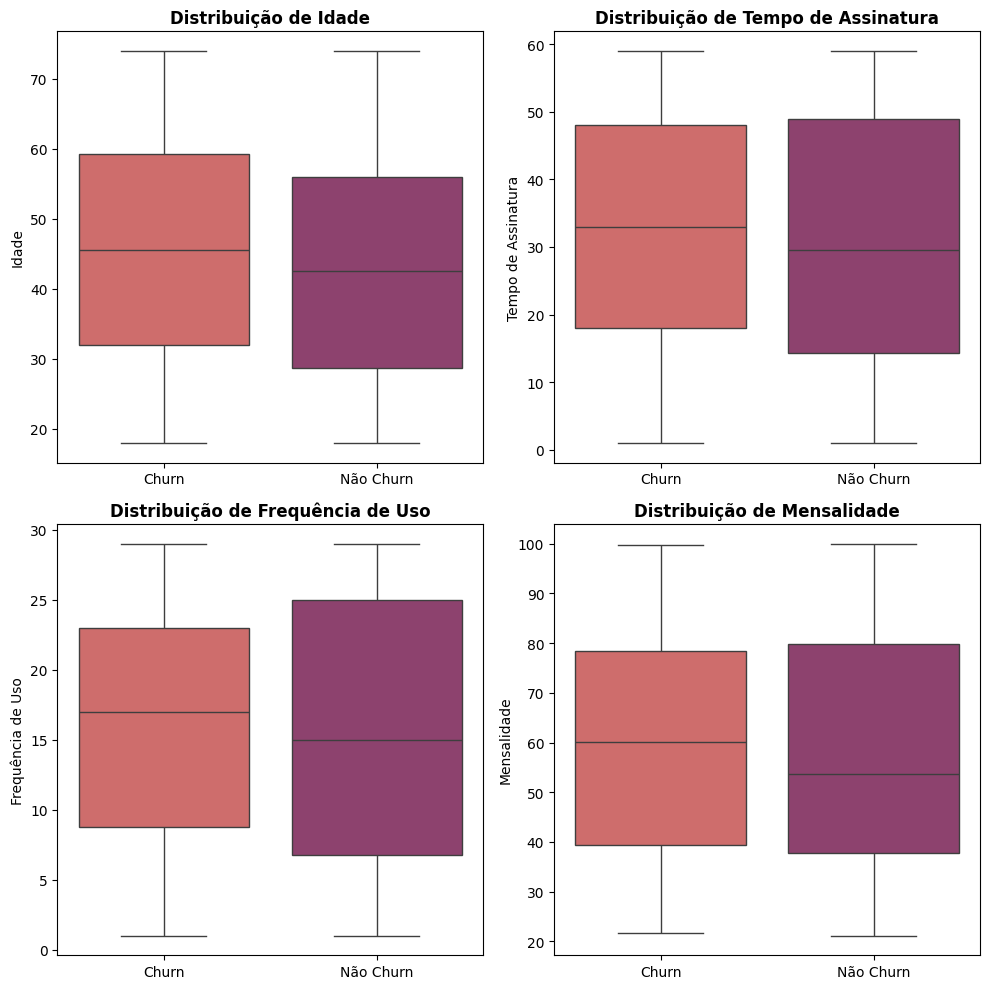

In [168]:
# Dicionario centralizado de nomes
mapa_nomes = {
  'idade': 'Idade',
  'tempo_assinatura_meses': 'Tempo de Assinatura',
  'frequencia_uso_mensal': 'Frequência de Uso',
  'mensalidade': 'Mensalidade',
  'cancelou': 'Cancelamento'
}

# Filtra as variaveis numericas para o plot
vars_para_plot = []
for col in mapa_nomes.keys():
  if col != 'cancelou': vars_para_plot.append(col)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes_flat = axes.flatten()

for i, var in enumerate(vars_para_plot):
  sns.boxplot(data=df, x='cancelou', y=var, ax=axes_flat[i], palette=paleta, hue='cancelou', legend=False)

  nome_display = mapa_nomes[var] # Obtem o nome a partir do dicionario

  axes_flat[i].set_title(f'Distribuição de {nome_display}', fontweight='bold')
  axes_flat[i].set_ylabel(nome_display)
  axes_flat[i].set_xlabel('')
  axes_flat[i].set_xticks([0, 1])
  axes_flat[i].set_xticklabels(leg_labels_churn)

plt.tight_layout()
plt.show()

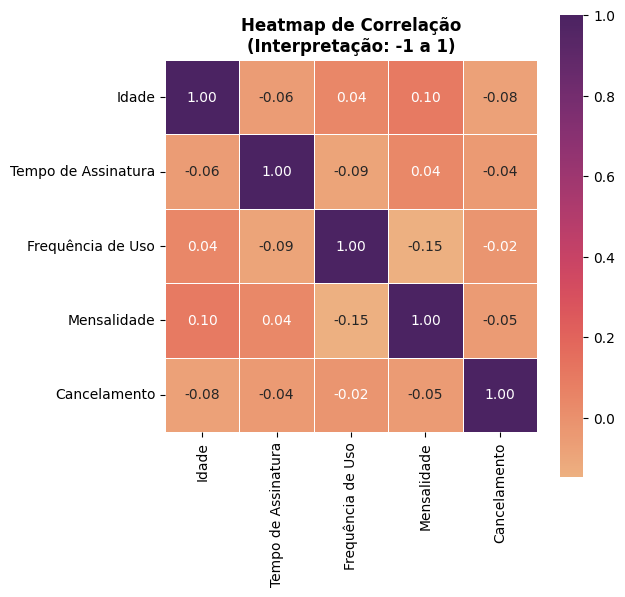

In [169]:
# Seleciona apenas as colunas numericas para o calculo
colunas_numericas = df.select_dtypes(include=[np.number]).drop(columns=['cliente_id'])

# Renomeia as colunas usando o dicionario mapa_nomes
rename_dict = {}
for col in colunas_numericas.columns:
  if col in mapa_nomes: rename_dict[col] = mapa_nomes[col]

corr = colunas_numericas.rename(columns=rename_dict).corr()

plt.figure(figsize=(6, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap=paleta, square=True, linewidths=.5)
plt.title('Heatmap de Correlação\n(Interpretação: -1 a 1)', fontweight='bold')
plt.show()

In [170]:
# ==========================================
# PERFIL MÉDIO: CHURN vs NÃO CHURN
# ==========================================

# Objetivo:
# - comparar o comportamento médio entre clientes que cancelam e os que permanecem
# - identificar variáveis com potencial poder explicativo para churn

# Denominador:
# - total de clientes dentro de cada classe de churn

display(Markdown("## Perfil médio: Churn vs Não churn"))
display(Markdown("---"))

perfil = df.groupby('cancelou')[[
    'idade',
    'tempo_assinatura_meses',
    'frequencia_uso_mensal',
    'mensalidade'
]].mean().T.round(2)

perfil.columns = ['Sem Churn', 'Churn']

display(
    perfil.style
        .format("{:.2f}")
        .background_gradient(
            cmap=sns.color_palette(paleta, as_cmap=True),
            axis=None
        )
)

## Perfil médio: Churn vs Não churn

---

,Sem Churn,Churn
idade,46.03,43.29
tempo_assinatura_meses,31.37,29.66
frequencia_uso_mensal,16.08,15.71
mensalidade,59.83,57.33


In [171]:
# ==========================================
# TAXA DE CHURN POR REGIÃO E GRUPO DE TEMPO
# ==========================================

# Objetivo:
# - identificar se o churn varia conforme região e estágio do cliente
# - detectar interações entre fatores geográficos e comportamento do cliente

# Denominador:
# - total de clientes dentro de cada combinação (região × grupo_tempo)

display(Markdown("## Taxa de Churn por região vs Tempo de assinatura"))
display(Markdown("---"))

tabela = (
    df.groupby(['regiao', 'grupo_tempo'], observed=False)['cancelou']
    .mean()
    .mul(100)
    .round(2)
    .unstack()
)

tabela.columns.name = None
tabela.index.name = "Região"

display(
    tabela.style
        .format("{:.2f}%")
        .background_gradient(
            cmap=sns.color_palette(paleta, as_cmap=True)
        )
)

## Taxa de Churn por região vs Tempo de assinatura

---

,Até 6 meses,7 a 24 meses,Acima de 24 meses
Região,,,
Centro-Oeste,57.14%,10.00%,23.33%
Nordeste,0.00%,55.56%,41.67%
Norte,20.00%,27.27%,20.00%
Sudeste,40.00%,30.77%,22.22%
Sul,nan%,22.22%,22.22%


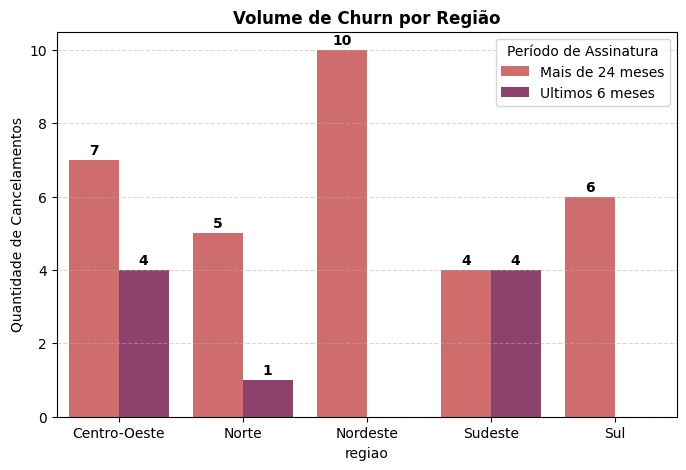

In [172]:
# Volume de churn por regiao dentro de cada grupo
plot_churn_regiao = cancelaram[(cancelaram['grupo_cancelamento'] != 'Outros Periodos / Ativos')]

iniciar_grafico(
  titulo='Volume de Churn por Região',
  xlabel='',
  ylabel='Quantidade de Cancelamentos'
)

# Plota o grafico
ax = sns.countplot(data=plot_churn_regiao, x='regiao', hue='grupo_cancelamento', palette=paleta)
plt.legend(title='Período de Assinatura')
rotulo_acima_da_barra(ax, '{:.0f}')

plt.show()

In [173]:
# ==========================================
# CHURN POR REGIÃO (RISCO + IMPACTO)
# ==========================================

# Objetivo:
# - Comparar a taxa e participação de Churn de cada Região

# Participação no churn total:
# - mostra o peso de cada região dentro do total de churn da base

# Denominadores:
# - Clientes: total de registros da base na região
# - Churn: total de clientes que cancelaram da região (para a taxa via média)
# - Taxa churn (%): O risco local - porporção de cancelamentos da região
# - Participação churn (%): O peso da região no prejuízo total - porporção da
# região relativo ao total de cancelamentos

display(Markdown("## Churn por Região"))
display(Markdown("---"))

regiao = df.groupby('regiao')['cancelou'].agg([
    ('Clientes', 'count'), # Base total da região
    ('Churn', 'sum'),      # Total de cancelamentos
    ('Taxa churn', 'mean') # Proporção de cancelamentos da região
]).reset_index()

regiao['Taxa churn (%)'] = (regiao['Taxa churn'] * 100).round(2)

regiao['Participação churn (%)'] = (
    regiao['Churn'] / regiao['Churn'].sum() * 100
).round(2)

regiao = regiao.drop(columns=['Taxa churn'])

display(regiao.sort_values('Taxa churn (%)', ascending=False))

# Região com maior taxa de churn (risco)
maior_risco = regiao.loc[regiao['Taxa churn (%)'].idxmax(), ['regiao', 'Taxa churn (%)']]

# Região com maior participação no churn (impacto)
maior_impacto = regiao.loc[regiao['Participação churn (%)'].idxmax(), ['regiao', 'Participação churn (%)']]

display(Markdown("---"))
print(f"Maior taxa de churn: {maior_risco['regiao']} ({maior_risco['Taxa churn (%)']:.2f}%) - risco dentro da região")
print(f"Maior participação no churn: {maior_impacto['regiao']} ({maior_impacto['Participação churn (%)']:.2f}%)- impacto no total")

## Churn por Região

---

,regiao,Clientes,Churn,Taxa churn (%),Participação churn (%)
1,Nordeste,35,15,42.86,26.79
3,Sudeste,41,12,29.27,21.43
0,Centro-Oeste,47,12,25.53,21.43
4,Sul,36,8,22.22,14.29
2,Norte,41,9,21.95,16.07


---

Maior taxa de churn: Nordeste (42.86%) - risco dentro da região
Maior participação no churn: Nordeste (26.79%)- impacto no total


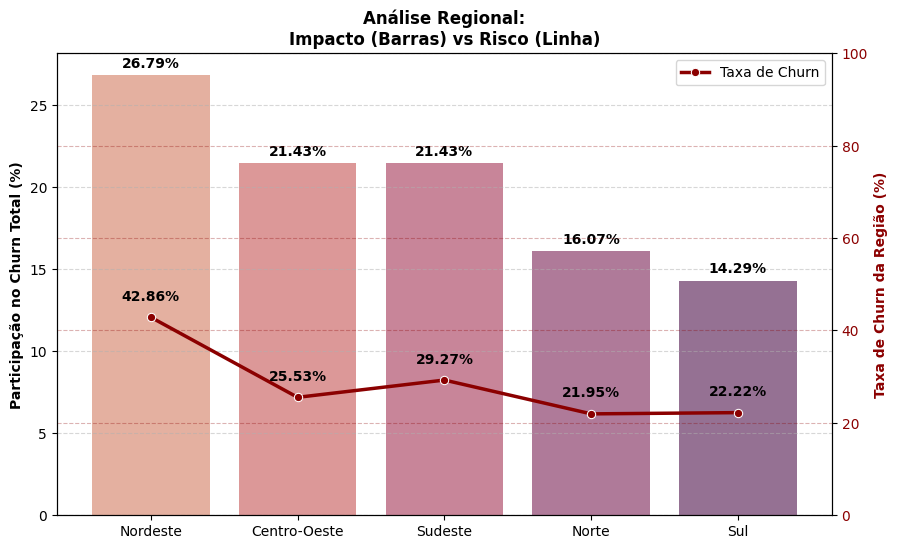

In [174]:
plot_churn_regiao_risco = regiao.sort_values('Participação churn (%)', ascending=False)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_title('Análise Regional:\nImpacto (Barras) vs Risco (Linha)', fontweight='bold')

# 1. Barras para participacao no churn total
ax1.grid(axis='y', linestyle='--', alpha=0.5) # Configuracao do grid para o ax1
sns.barplot(data=plot_churn_regiao_risco, x='regiao', y='Participação churn (%)', hue='regiao', ax=ax1, palette=paleta, alpha=0.7, legend=False)
ax1.set_xlabel('')
ax1.set_ylabel('Participação no Churn Total (%)', fontweight='bold')

# 2. Linha para taxa de churn da regiao
ax2 = ax1.twinx()
cor_linha = 'darkred'

ax2.grid(True, color=cor_linha, linestyle='--', alpha=0.3) # Configuracao do grid para o ax2
sns.lineplot(data=plot_churn_regiao_risco, x='regiao', y='Taxa churn (%)', ax=ax2, color=cor_linha, marker='o', linewidth=2.5, label='Taxa de Churn')
ax2.set_ylabel('Taxa de Churn da Região (%)', fontweight='bold', color=cor_linha)
ax2.tick_params(axis='y', labelcolor=cor_linha)
ax2.set_ylim(0, 100)

# Adicionando rótulos de dados
for i, p in enumerate(plot_churn_regiao_risco['Participação churn (%)']):
  ax1.text(i, p + 0.3, f'{p}%', ha='center', va='bottom', fontweight='bold')

for i, t in enumerate(plot_churn_regiao_risco['Taxa churn (%)']):
  ax2.text(i, t + 3, f'{t}%', ha='center', va='bottom', color='black', fontweight='bold')

plt.show()

In [175]:
# Criação de variável categórica a partir da idade

df['faixa_etaria'] = pd.cut(
    df['idade'],
    bins=[0, 25, 35, 45, 60, 100],
    labels=['18-25', '26-35', '36-45', '46-60', '60+']
)

In [176]:
# ==========================================
# CHURN POR FAIXA ETÁRIA (INDEPENDENTE DO TEMPO)
# ==========================================

# Objetivo:
# - medir risco de churn isolando o efeito da idade
# - comparar comportamento entre diferentes faixas etárias sem interferência do tempo

# Denominador:
# - total de clientes dentro de cada faixa etária

display(Markdown("## Churn por faixa etária (independente do tempo)"))
display(Markdown("---"))

tabela = pd.crosstab(
    df['faixa_etaria'],
    df['cancelou'],
    normalize='index'
).mul(100).round(2)

tabela = tabela[[1]]
tabela.columns = ['Churn (%)']

tabela.index.name = "Faixa etária"

display(
    tabela.style
        .format("{:.2f}%")
        .background_gradient(cmap=sns.color_palette(paleta, as_cmap=True))
)

display(Markdown("---"))
maior_churn = tabela['Churn (%)'].idxmax()
valor_maior_churn = tabela['Churn (%)'].max()

print(f"Maior taxa de churn por faixa etária: {maior_churn} ({valor_maior_churn:.2f}%)")

## Churn por faixa etária (independente do tempo)

---

,Churn (%)
Faixa etária,
18-25,35.48%
26-35,33.33%
36-45,25.00%
46-60,26.00%
60+,23.91%


---

Maior taxa de churn por faixa etária: 18-25 (35.48%)


In [177]:
# ==========================================
# CHURN POR FAIXA ETÁRIA E GRUPO DE TEMPO
# ==========================================

# Objetivo:
# - analisar a interação entre idade e tempo de relacionamento no risco de churn
# - identificar segmentos mais vulneráveis ao cancelamento

# Denominador:
# - total de clientes dentro de cada célula (faixa_etaria × grupo_tempo)

display(Markdown("## Churn por faixa etária e grupo de tempo"))
display(Markdown("---"))

tabela_churn_faixa = pd.crosstab(
    df['faixa_etaria'],
    df['grupo_tempo'],
    values=df['cancelou'],
    aggfunc='mean',
    normalize=False
).mul(100).round(2)

tabela_churn_faixa.columns.name = "Grupo de tempo"
tabela_churn_faixa.index.name = "Faixa etária"

display(
    tabela_churn_faixa.style
        .format("{:.2f}%")
        .background_gradient(cmap=sns.color_palette(paleta, as_cmap=True))
)

maior_tempo = tabela_churn_faixa.max().max()
grupo_maior_tempo = tabela_churn_faixa.max().idxmax()
faixa_maior_tempo = tabela_churn_faixa[grupo_maior_tempo].idxmax()

display(Markdown("---"))
print(f"Maior churn no grupo de tempo: {grupo_maior_tempo} + {faixa_maior_tempo} ({maior_tempo:.2f}%)")
display(Markdown("---"))

for col in tabela_churn_faixa.columns:
    faixa = tabela_churn_faixa[col].idxmax()
    valor = tabela_churn_faixa[col].max()

    print(f"Maior churn em {col}: {faixa} ({valor:.2f}%)")

## Churn por faixa etária e grupo de tempo

---

Grupo de tempo,Até 6 meses,7 a 24 meses,Acima de 24 meses
Faixa etária,,,
18-25,66.67%,37.50%,30.00%
26-35,40.00%,57.14%,23.81%
36-45,25.00%,33.33%,23.33%
46-60,42.86%,17.65%,26.92%
60+,20.00%,21.43%,25.93%


---

Maior churn no grupo de tempo: Até 6 meses + 18-25 (66.67%)


---

Maior churn em Até 6 meses: 18-25 (66.67%)
Maior churn em 7 a 24 meses: 26-35 (57.14%)
Maior churn em Acima de 24 meses: 18-25 (30.00%)


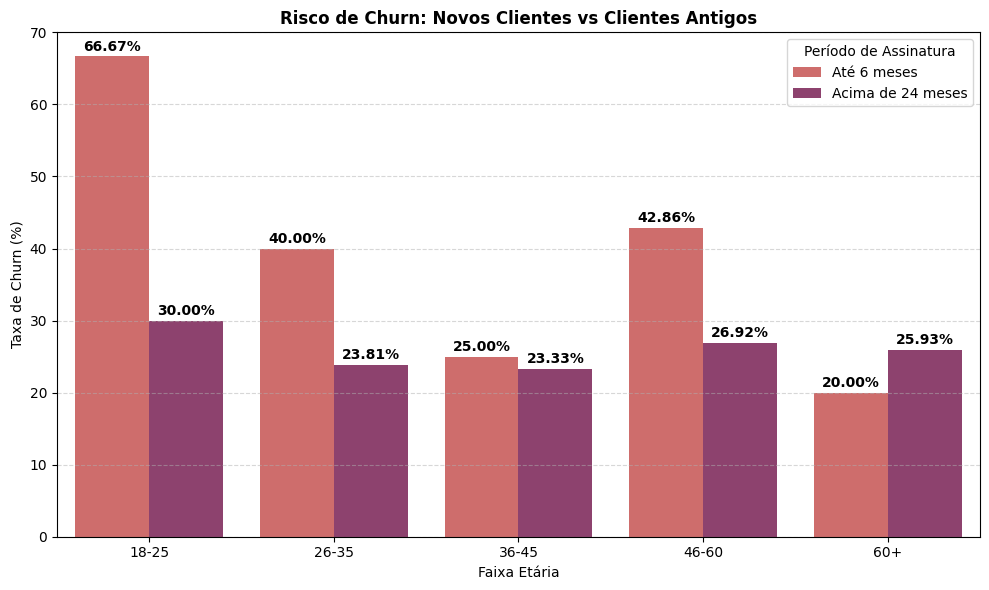

In [178]:
# Filtra apenas as colunas de interesse para o grafico
plot_churn_faixa = tabela_churn_faixa[['Até 6 meses', 'Acima de 24 meses']].reset_index().melt(id_vars='Faixa etária')

iniciar_grafico(
  titulo='Risco de Churn: Novos Clientes vs Clientes Antigos',
  xlabel='Faixa Etária',
  ylabel='Taxa de Churn (%)',
  figsize=(10, 6)
)

ax = sns.barplot(data=plot_churn_faixa, x='Faixa etária', y='value', hue='Grupo de tempo', palette=paleta)
plt.legend(title='Período de Assinatura')

# Adiciona rotulos nas barras
rotulo_acima_da_barra(ax)

plt.tight_layout()
plt.show()

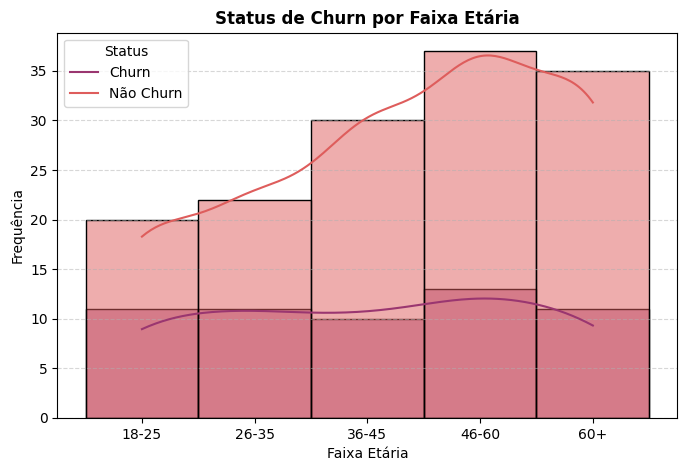

In [179]:
iniciar_grafico(
  titulo='Status de Churn por Faixa Etária',
  xlabel='Faixa Etária',
  ylabel='Frequência'
)

# Plota o histograma
ax = sns.histplot(data=df, x='faixa_etaria', hue='cancelou', kde=True, palette=paleta)
plt.legend(labels=['Churn', 'Não Churn'], title='Status')

plt.show()

In [180]:
# Utilize testes estatísticos para verificar se há uma relação significativa entre tempo de assinatura e taxa de cancelamento.

# Hipóteses
# H0 (hipótese nula): O tempo médio de assinatura é igual entre clientes que cancelam e clientes que não cancelam.
# → Não existe relação entre tempo de assinatura e churn.

# H1 (hipótese alternativa): O tempo médio de assinatura é diferente entre clientes que cancelam e clientes que não cancelam.
# → Existe relação entre tempo de assinatura e churn.

# Cria os conjuntos que serão analisados pelo teste t

amostra_cancelados = cancelaram['tempo_assinatura_meses']
amostra_ativos = ativos['tempo_assinatura_meses']


In [181]:
# Aplica o teste t sobre os conjuntos designados

resultado_t = ttest_ind(amostra_cancelados, amostra_ativos, equal_var=False)
resultado_t

TtestResult(statistic=np.float64(-0.5899541991646156), pvalue=np.float64(0.556648599134378), df=np.float64(93.2255610238105))

In [182]:
# Armazena o p_value em uma variável

p_valor = resultado_t.pvalue
p_valor

np.float64(0.556648599134378)

In [183]:
# Captura a média de cada grupo, anteriormente calculada

media_ativos = perfil.loc['tempo_assinatura_meses', 'Sem Churn']
media_cancelamento = perfil.loc['tempo_assinatura_meses', 'Churn']

# Exibe as médias de tempo de assinatura de cada grupo

print(f'A média de tempo de assinatura entre os clientes ativos é de {media_ativos} meses, enquanto que a média para clientes que cancelaram o serviço é {media_cancelamento}')

# Exibe o resultado do teste t

if p_valor < 0.05:
    display(Markdown(f'A análise do teste t encontrou o valor de p igual a {p_valor:.2f}, demonstrando que **há evidência estatística de que o tempo de assinatura difere** entre clientes que cancelam e clientes que permanecem.'))
else:
    display(Markdown(f'A análise do teste t encontrou o valor de p igual a {p_valor:.2f}, demonstrando que as diferenças observadas no tempo de assinatura entre clientes que cancelam e os que permanecem **não são estatisticamente significativas**.'))

A média de tempo de assinatura entre os clientes ativos é de 31.37 meses, enquanto que a média para clientes que cancelaram o serviço é 29.66


A análise do teste t encontrou o valor de p igual a 0.56, demonstrando que as diferenças observadas no tempo de assinatura entre clientes que cancelam e os que permanecem **não são estatisticamente significativas**.

In [184]:
# Análise se há diferença significativa entre tempo de cancelamento e outras variáveis

# Tecnicamente seria possível comparar os grupos usando vários testes t, mas isso não é recomendado porque aumenta o risco de falsos positivos.
# O ANOVA é o teste estatístico apropriado para comparar médias entre mais de dois grupos em um único passo, mantendo o controle do erro. Caso o ANOVA encontrasse alguma diferença significativa, testes adicionais seriam necessários para identificar quais grupos diferem entre si.
# Para faixa etária (variável categórica ordinal), o teste estatístico apropriado é o Kruskal–Wallis, que compara a distribuição dos grupos sem assumir normalidade ou continuidade. Ele converte as categorias em códigos ordenados (cat.codes), permitindo avaliar se há diferença significativa entre os grupos de tempo. Caso o teste encontrasse diferença significativa, testes adicionais seriam necessários para identificar quais grupos diferem entre si.


In [185]:
# FAIXA ETÁRIA: a faixa etária dos clientes difere significativamente entre os grupos de churn?

# Obtém os subconjuntos que serão analisados pelo teste Kruskal–Wallis, a partir de análise previamente realizada

faixa_ate6 = df[(df['grupo_tempo'] == 'Até 6 meses')]['faixa_etaria'].cat.codes
faixa_7a24 = df[(df['grupo_tempo'] == '7 a 24 meses')]['faixa_etaria'].cat.codes
faixa_24mais = df[(df['grupo_tempo'] == 'Acima de 24 meses')]['faixa_etaria'].cat.codes
faixa_ativos = df[df['cancelou'] == 0]['faixa_etaria'].cat.codes

In [186]:
# Aplica o teste Kruskal–Wallis sobre os conjuntos designados

kruskal_faixa = kruskal(
    faixa_ate6,
    faixa_7a24,
    faixa_24mais,
    faixa_ativos
)

kruskal_faixa

KruskalResult(statistic=np.float64(1.8952587034528292), pvalue=np.float64(0.5944280777722701))

In [187]:
# Armazena o p_value em uma variável

p_kruskal_faixa = kruskal_faixa.pvalue
p_kruskal_faixa

np.float64(0.5944280777722701)

In [188]:
# Exibe o resultado do teste Kruskal–Wallis

if p_kruskal_faixa < 0.05:
    display(Markdown(f'O teste Kruskal–Wallis encontrou o valor de p igual a {p_kruskal_faixa:.2f}, indicando que **a distribuição das faixas etárias difere significativamente** entre os grupos de tempo de assinatura.'))
else:
    display(Markdown(f'O teste Kruskal–Wallis encontrou o valor de p igual a {p_kruskal_faixa:.2f}, indicando que **não há diferença significativa** na distribuição das faixas etárias entre os grupos de tempo de assinatura.'))

O teste Kruskal–Wallis encontrou o valor de p igual a 0.59, indicando que **não há diferença significativa** na distribuição das faixas etárias entre os grupos de tempo de assinatura.

In [189]:
# Ou seja, faixa etária NÃO é um fator determinante para churn.

In [190]:
# FREQUÊNCIA DE USO: a frequência de uso mensal difere significativamente entre os grupos de churn?

# Cria os conjuntos que serão analisados pelo teste ANOVA:
# 1: frequência de uso mensal dos clientes que cancelaram com até 6 meses de assinatura
# 2: frequência de uso mensal dos clientes que cancelaram com 7 a 24 meses de assinatura
# 3: frequência de uso mensal dos clientes que cancelaram com mais de 24 meses de assinatura
# 4: frequência de uso mensal dos clientes ativos

freq_ate6 = df[(df['grupo_tempo'] == 'Até 6 meses') & (df['cancelou'] == 1)]['frequencia_uso_mensal']
freq_7a24 = df[(df['grupo_tempo'] == '7 a 24 meses') & (df['cancelou'] == 1)]['frequencia_uso_mensal']
freq_24mais = df[(df['grupo_tempo'] == 'Acima de 24 meses') & (df['cancelou'] == 1)]['frequencia_uso_mensal']
freq_ativos = df[df['cancelou'] == 0]['frequencia_uso_mensal']

In [191]:
# Aplica o teste ANOVA sobre os conjuntos designados

anova_frequencia = f_oneway(
    freq_ate6,
    freq_7a24,
    freq_24mais,
    freq_ativos
)

anova_frequencia

F_onewayResult(statistic=np.float64(0.8982823712625803), pvalue=np.float64(0.4430736536826563))

In [192]:
# Armazena o p_value em uma variável

p_anova_frequencia = anova_frequencia.pvalue
p_anova_frequencia

np.float64(0.4430736536826563)

In [193]:
# Exibe o resultado do teste ANOVA

if p_anova_frequencia < 0.05:
    display(Markdown(f'O teste ANOVA para frequência de uso encontrou o valor de p igual a {p_anova_frequencia:.2f}, indicando que **pelo menos um dos grupos possui frequência média de uso significativamente diferente** dos demais'))
else:
    display(Markdown(f'O teste ANOVA para frequência de uso encontrou o valor de p igual a {p_anova_frequencia:.2f}, indicando que as diferenças observadas entre os grupos de churn **não são estatisticamente significativas**.'))

O teste ANOVA para frequência de uso encontrou o valor de p igual a 0.44, indicando que as diferenças observadas entre os grupos de churn **não são estatisticamente significativas**.

In [194]:
# Os 4 conjuntos analisados têm frequência de uso parecidas. Ou seja, não existe evidência estatística de que clientes que cancelam cedo ou tarde usam o serviço de forma diferente.

In [195]:
# MENSALIDADE: o valor da mensalidade difere significativamente entre os grupos de churn?

# Cria os conjuntos que serão analisados pelo teste ANOVA:
# 1: valor da mensalidade entre os clientes que cancelaram com até 6 meses de assinatura
# 2: valor da mensalidade entre os clientes que cancelaram com 7 a 24 meses de assinatura
# 3: valor da mensalidade entre os clientes que cancelaram com mais de 24 meses de assinatura
# 4: valor da mensalidade entre os clientes ativos

mens_ate6 = df[(df['grupo_tempo'] == 'Até 6 meses') & (df['cancelou'] == 1)]['mensalidade']
mens_7a24 = df[(df['grupo_tempo'] == '7 a 24 meses') & (df['cancelou'] == 1)]['mensalidade']
mens_24mais = df[(df['grupo_tempo'] == 'Acima de 24 meses') & (df['cancelou'] == 1)]['mensalidade']
mens_ativos = df[df['cancelou'] == 0]['mensalidade']

In [196]:
# Aplica o teste ANOVA sobre os conjuntos designados

anova_mensalidade = f_oneway(
    mens_ate6,
    mens_7a24,
    mens_24mais,
    mens_ativos
)

anova_mensalidade

F_onewayResult(statistic=np.float64(1.2714417328036827), pvalue=np.float64(0.2853684672526544))

In [197]:
# Armazena o p_value em uma variável

p_anova_mensalidade = anova_mensalidade.pvalue
p_anova_mensalidade

np.float64(0.2853684672526544)

In [198]:
# Exibe o resultado do teste ANOVA

if p_anova_mensalidade < 0.05:
    display(Markdown(f'O teste ANOVA para valor da mensalidade encontrou o valor de p igual a {p_anova_mensalidade:.2f}, indicando que **pelo menos um dos grupos possui valor médio da mensalidade significativamente diferente** dos demais'))
else:
    display(Markdown(f'O teste ANOVA para valor da mensalidade encontrou o valor de p igual a {p_anova_mensalidade:.2f}, indicando que as diferenças observadas entre os grupos de churn **não são estatisticamente significativas**.'))

O teste ANOVA para valor da mensalidade encontrou o valor de p igual a 0.29, indicando que as diferenças observadas entre os grupos de churn **não são estatisticamente significativas**.

In [199]:
# O valor da mensalidade NÃO difere entre os grupos de churn. Ou seja, clientes que cancelam cedo, tarde ou nunca cancelam pagam praticamente o mesmo valor.

In [200]:
# REGIÃO: a região dos clientes está associada ao churn?

# Obtém os clientes ativos por região a partir de análise anteriormente realizada

regiao['Sem Churn'] = regiao['Clientes'] - regiao['Churn']
regiao = regiao.set_index('regiao')

# Prepara a matriz de contingência para o teste qui-quadrado (uma tabela que contém apenas as contagens brutas de cada combinação de categorias; o teste compara esses valores observados com os valores esperados caso não exista relação entre as variáveis)

tabela_regiao = regiao[['Churn', 'Sem Churn']]
tabela_regiao


,Churn,Sem Churn
regiao,,
Centro-Oeste,12,35
Nordeste,15,20
Norte,9,32
Sudeste,12,29
Sul,8,28


In [201]:
# Aplica o teste qui-quadrado

qui2, p_valor, gl, esperados = chi2_contingency(tabela_regiao)

resultado_qui = pd.DataFrame({
    'Valor': [qui2, p_valor, gl],
}, index=[
    'Estatística Qui-Quadrado',
    'p-valor',
    'Graus de Liberdade'
])

resultado_qui = resultado_qui.reset_index().rename(columns={'index': 'Métrica'})

resultado_qui


,Métrica,Valor
0,Estatística Qui-Quadrado,5.347142
1,p-valor,0.253496
2,Graus de Liberdade,4.000000


In [202]:
# Exibe a matriz de valores esperados - ou seja, o que seria esperado se não houvesse relação entre região e churn

esperados_df = pd.DataFrame(
    esperados,
    index=tabela_regiao.index,
    columns=tabela_regiao.columns
)

esperados_df

,Churn,Sem Churn
regiao,,
Centro-Oeste,13.16,33.84
Nordeste,9.80,25.20
Norte,11.48,29.52
Sudeste,11.48,29.52
Sul,10.08,25.92


In [203]:
# Armazena o p_value em uma variável

p_qui = p_valor
p_qui

np.float64(0.2534960934070539)

In [204]:
# Exibe o resultado do teste qui-quadrado

if p_qui < 0.05:
    display(Markdown(f'O teste qui-quadrado encontrou o valor de p igual a {p_qui:.2f}, indicando que **a região está associada ao churn**, com diferenças significativas na distribuição entre os grupos.'))
else:
    display(Markdown(f'O teste qui-quadrado encontrou o valor de p igual a {p_qui:.2f}, indicando que a distribuição de churn entre as regiões **não difere significativamente**.'))

O teste qui-quadrado encontrou o valor de p igual a 0.25, indicando que a distribuição de churn entre as regiões **não difere significativamente**.

In [205]:
def calcular_tamanho_amostra(N, confianca=0.95, margem_erro=0.02, p=0.5):
    """
    Calcula o tamanho de amostra necessário para uma população finita.

    Parâmetros:
    N (int): Tamanho total da população (100.000 clientes).
    confianca (float): Nível de confiança (0.95 = 95%).
    margem_erro (float): Margem de erro admissível (ex: 0.02 = 2%).
    p (float): Proporção populacional estimada (0.5 = 50% para variância máxima).
    """
    # Define o valor crítico de Z com base na confiança de 95%
    if confianca == 0.95:
        Z = 1.96
    else:
        Z = 1.645 # Caso fosse 90%

    # Aplicação matemática da fórmula de Cochran para população finita
    numerador = (Z**2) * p * (1 - p) / (margem_erro**2)
    denominador = 1 + (((Z**2) * p * (1 - p)) / ((margem_erro**2) * N))

    n = numerador / denominador
    return math.ceil(n) # Arredonda para cima para garantir o número inteiro de clientes

# ==============================================================================
# CONFIGURAÇÃO DOS CENÁRIOS
# ==============================================================================
N_total = 100000

# Conta quantas linhas reais existem no seu DataFrame atual carregado da internet
tamanho_da_sua_base = len(df)

# Cenário A: Confiança de 95%, Margem de Erro de 2% e Proporção Conservadora de 50% (p=0.5)
n_2_porcento = calcular_tamanho_amostra(N=N_total, margem_erro=0.02, p=0.5)

# Cenário B: Confiança de 95%, Margem de Erro de 10% e Proporção Conservadora de 50% (p=0.5)
n_10_porcento = calcular_tamanho_amostra(N=N_total, margem_erro=0.10, p=0.5)

# ==============================================================================
# RESULTADOS
# ==============================================================================

print(f"Registros identificados na sua base atual (clientes.csv): {tamanho_da_sua_base}")
print("-" * 70)
print(f"Cenário 1 (Erro de 2% dado p=0.5): Amostra necessária = {n_2_porcento} clientes")
if tamanho_da_sua_base >= n_2_porcento:
    print("A base informada É SUFICIENTE!")
else:
    print(f"A base NÃO É SUFICIENTE. Faltam {n_2_porcento - tamanho_da_sua_base} registros.")

print("-" * 70)
print(f"Cenário 2 (Erro de 10% dado p=0.5): Amostra necessária = {n_10_porcento} clientes")
if tamanho_da_sua_base >= n_10_porcento:
    print("A base informada É SUFICIENTE (excede o mínimo com folga).")
else:
    print("A base NÃO É SUFICIENTE.")

Registros identificados na sua base atual (clientes.csv): 200
----------------------------------------------------------------------
Cenário 1 (Erro de 2% dado p=0.5): Amostra necessária = 2345 clientes
A base NÃO É SUFICIENTE. Faltam 2145 registros.
----------------------------------------------------------------------
Cenário 2 (Erro de 10% dado p=0.5): Amostra necessária = 96 clientes
A base informada É SUFICIENTE (excede o mínimo com folga).
